In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

file_path = '/content/drive/MyDrive/Colab Notebooks/mimic_los_extract.csv'
df = pd.read_csv(file_path)
df.head()


,subject_id,hadm_id,gender,age,admission_type,admittime,dischtime,los,diagnosis_code,procedure_code
0,10004235,24181354,M,47,URGENT,2196-02-24 14:38:00,2196-03-04 14:02:00,8.975000,42731,3897
1,10009628,25926192,M,58,URGENT,2153-09-17 17:08:00,2153-09-25 13:20:00,7.841667,2859,3961
2,10018081,23983182,M,79,URGENT,2134-08-18 02:02:00,2134-08-23 19:35:00,5.731250,E8798,5491
3,10006053,22942076,M,52,URGENT,2111-11-13 23:39:00,2111-11-15 17:20:00,1.736806,45989,391
4,10031404,21606243,F,82,URGENT,2113-08-04 18:46:00,2113-08-06 20:57:00,2.090972,E860,0W9D3ZZ


In [8]:
df.info()
df.describe(include="all")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   subject_id      275 non-null    int64  
 1   hadm_id         275 non-null    int64  
 2   gender          275 non-null    object 
 3   age             275 non-null    int64  
 4   admission_type  275 non-null    object 
 5   admittime       275 non-null    object 
 6   dischtime       275 non-null    object 
 7   los             275 non-null    float64
 8   diagnosis_code  275 non-null    object 
 9   procedure_code  275 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 21.6+ KB


,subject_id,hadm_id,gender,age,admission_type,admittime,dischtime,los,diagnosis_code,procedure_code
count,2.750000e+02,2.750000e+02,275,275.000000,275,275,275,275.000000,275,275
unique,NaN,NaN,2,NaN,9,275,275,NaN,216,130
top,NaN,NaN,M,NaN,EW EMER.,2147-12-19 00:00:00,2147-12-21 16:10:00,NaN,4019,NONE
freq,NaN,NaN,142,NaN,104,1,1,NaN,7,88
mean,1.001890e+07,2.513055e+07,NaN,61.043636,NaN,NaN,NaN,6.875530,NaN,NaN
std,1.212777e+04,2.907533e+06,NaN,14.440600,NaN,NaN,NaN,6.733832,NaN,NaN
min,1.000003e+07,2.004459e+07,NaN,21.000000,NaN,NaN,NaN,0.046528,NaN,NaN
25%,1.000787e+07,2.258313e+07,NaN,52.500000,NaN,NaN,NaN,2.692014,NaN,NaN
50%,1.001808e+07,2.517230e+07,NaN,60.000000,NaN,NaN,NaN,4.852778,NaN,NaN
75%,1.002626e+07,2.767155e+07,NaN,70.000000,NaN,NaN,NaN,8.768403,NaN,NaN


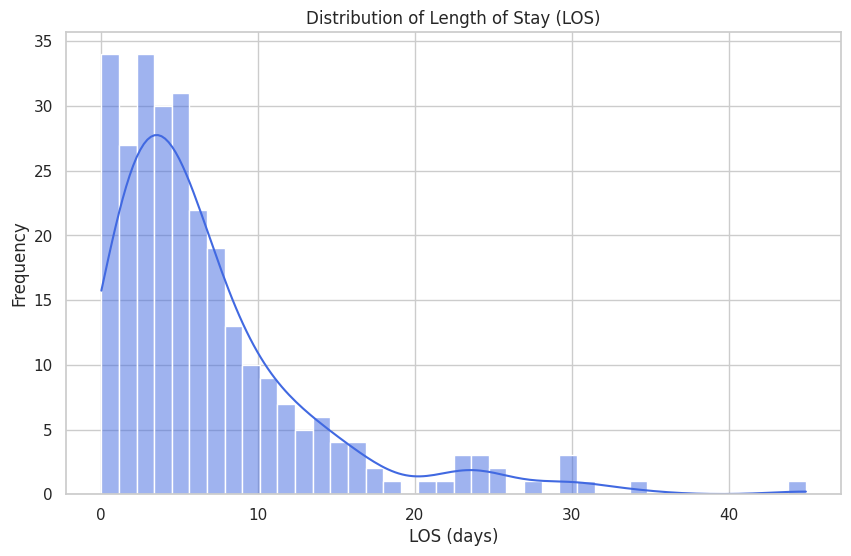

In [9]:
# 1.Distribution of length stay
plt.figure(figsize=(10,6))
sns.histplot(df['los'], bins=40, kde=True, color='royalblue')
plt.title("Distribution of Length of Stay (LOS)")
plt.xlabel("LOS (days)")
plt.ylabel("Frequency")
plt.show()


/tmp/ipykernel_10253/1661280874.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='admission_type', y='los', palette='Set2')


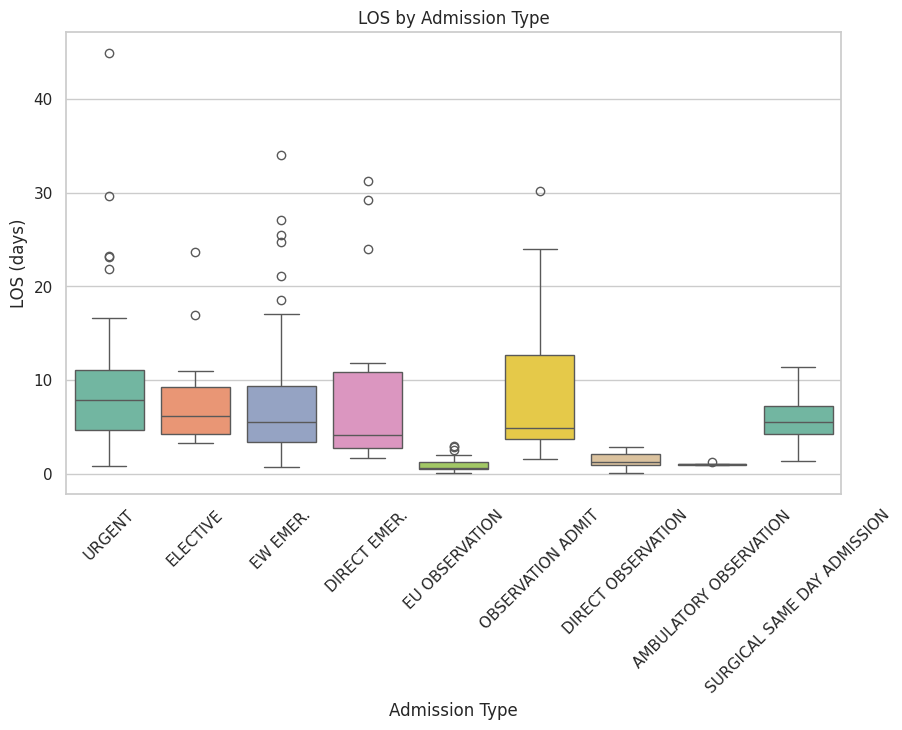

In [10]:
# 2. LOS by Admission Type
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='admission_type', y='los', palette='Set2')
plt.title("LOS by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("LOS (days)")
plt.xticks(rotation=45)
plt.show()


/tmp/ipykernel_10253/2522136419.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y='los', palette='coolwarm')


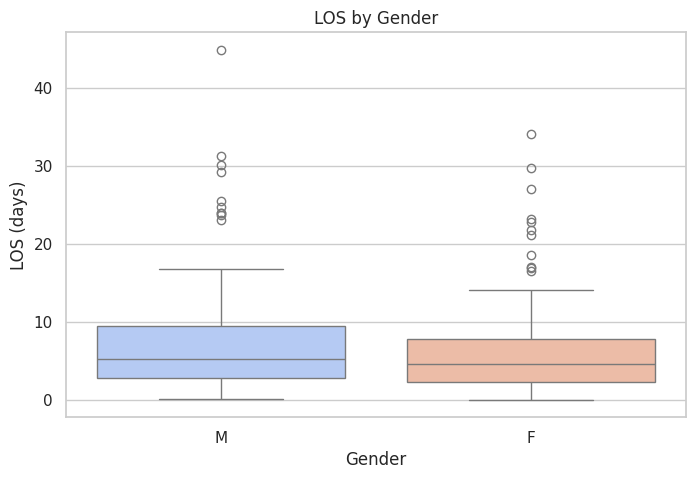

In [11]:
# 3. LOS by Gender
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='gender', y='los', palette='coolwarm')
plt.title("LOS by Gender")
plt.xlabel("Gender")
plt.ylabel("LOS (days)")
plt.show()


/tmp/ipykernel_10253/4056762511.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='age_group', y='los', palette='viridis')


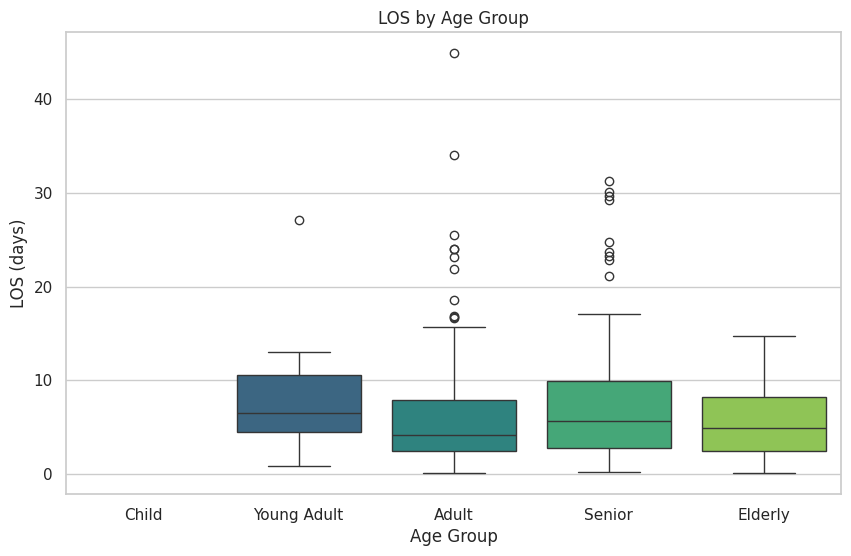

In [12]:
# 4. LOS by age group
df['age_group'] = pd.cut(
    df['age'],
    bins=[0,18,40,60,80,120],
    labels=['Child','Young Adult','Adult','Senior','Elderly']
)

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='age_group', y='los', palette='viridis')
plt.title("LOS by Age Group")
plt.xlabel("Age Group")
plt.ylabel("LOS (days)")
plt.show()

/tmp/ipykernel_10253/902649094.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_diag.values, y=top_diag.index, palette='magma')


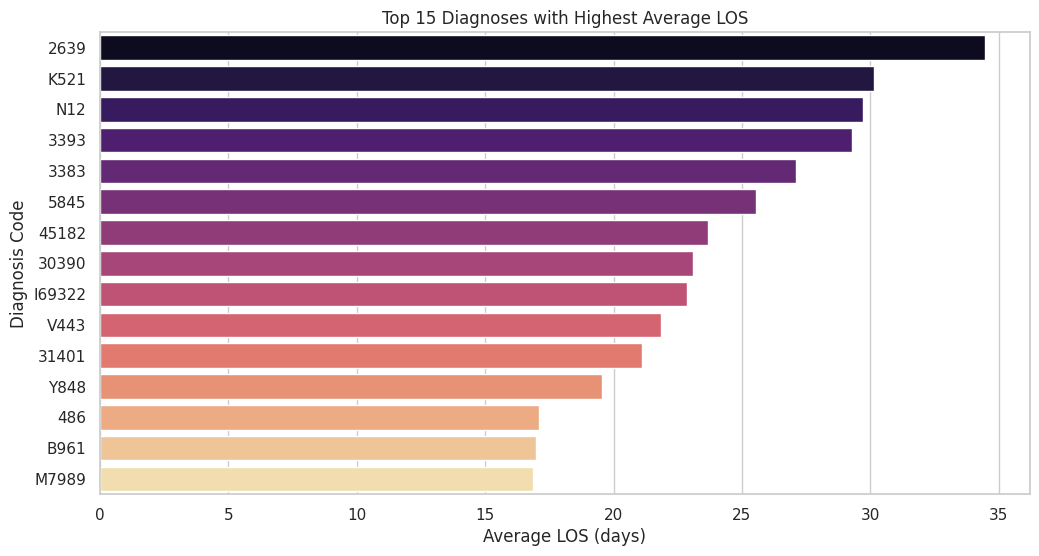

In [13]:
# 5. Top 15 Diagnoses with Highest LOS
top_diag = (
    df.groupby('diagnosis_code')['los']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))
sns.barplot(x=top_diag.values, y=top_diag.index, palette='magma')
plt.title("Top 15 Diagnoses with Highest Average LOS")
plt.xlabel("Average LOS (days)")
plt.ylabel("Diagnosis Code")
plt.show()


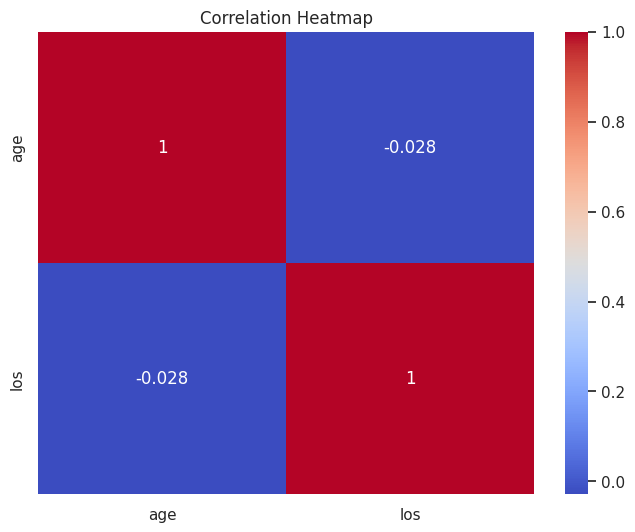

In [14]:
# 6. Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['age','los']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


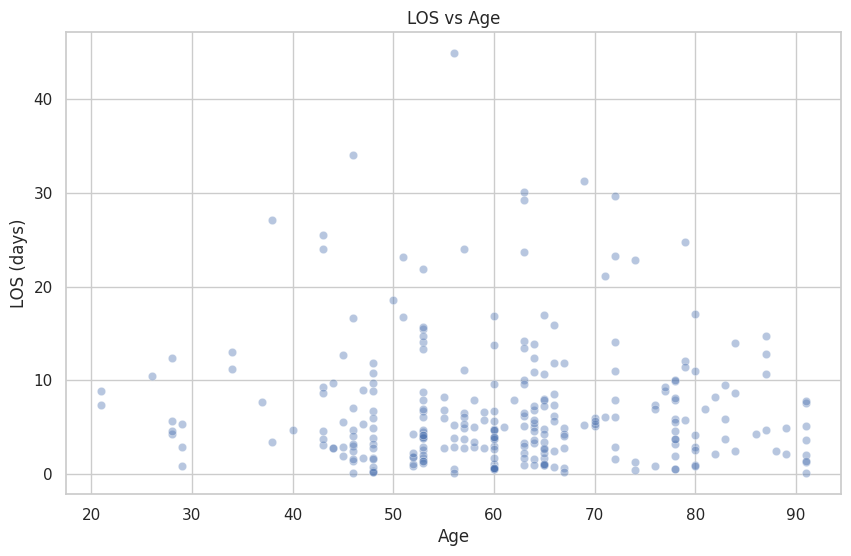

In [15]:
# 7. LOS vs Age Scatter Plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='age', y='los', alpha=0.4)
plt.title("LOS vs Age")
plt.xlabel("Age")
plt.ylabel("LOS (days)")
plt.show()


/tmp/ipykernel_10253/2101297904.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_proc.values, y=top_proc.index, palette='cubehelix')


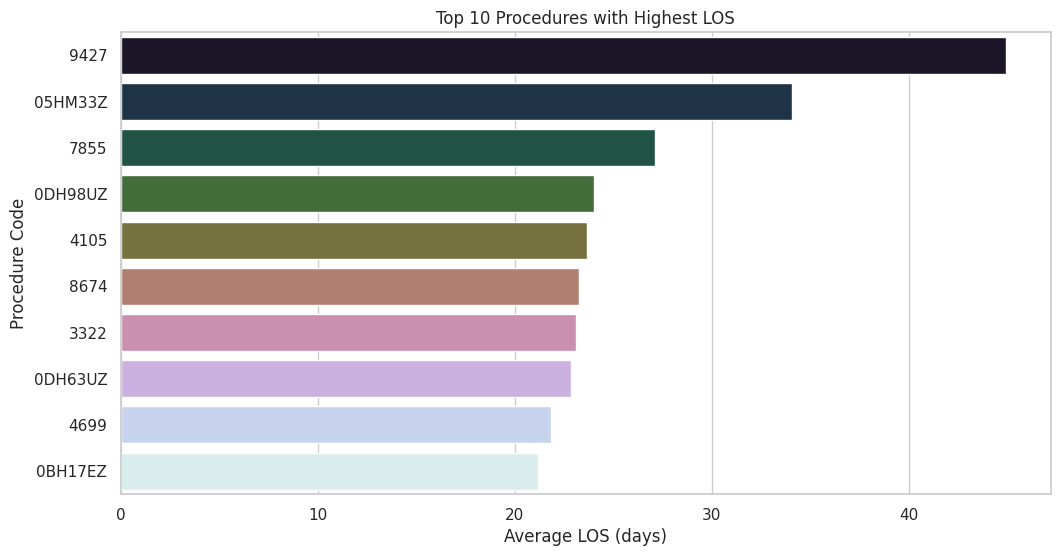

In [16]:
# 8. LOS by Procedure Code (Top 10)
top_proc = (
    df.groupby('procedure_code')['los']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(x=top_proc.values, y=top_proc.index, palette='cubehelix')
plt.title("Top 10 Procedures with Highest LOS")
plt.xlabel("Average LOS (days)")
plt.ylabel("Procedure Code")
plt.show()
